In [1]:
### Drosophila fruit flies data: https://www.cell.com/developmental-cell/fulltext/S1534-5807(22)00246-5

In [2]:
# pip install pygenstability

In [1]:
import ot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.ticker as ticker
import networkx as nx
import pandas as pd
import time
from geodesics import *

In [2]:
# Read in the datasets
corr_t1 = pd.read_csv('corr_matrix_E14_16.csv', index_col=0)
corr_t2 = pd.read_csv('corr_matrix_E16_18.csv', index_col=0)
corr_t3 = pd.read_csv('corr_matrix_L1.csv',     index_col=0)
corr_t4 = pd.read_csv('corr_matrix_L2.csv',     index_col=0)
corr_t5 = pd.read_csv('corr_matrix_L3.csv',     index_col=0)

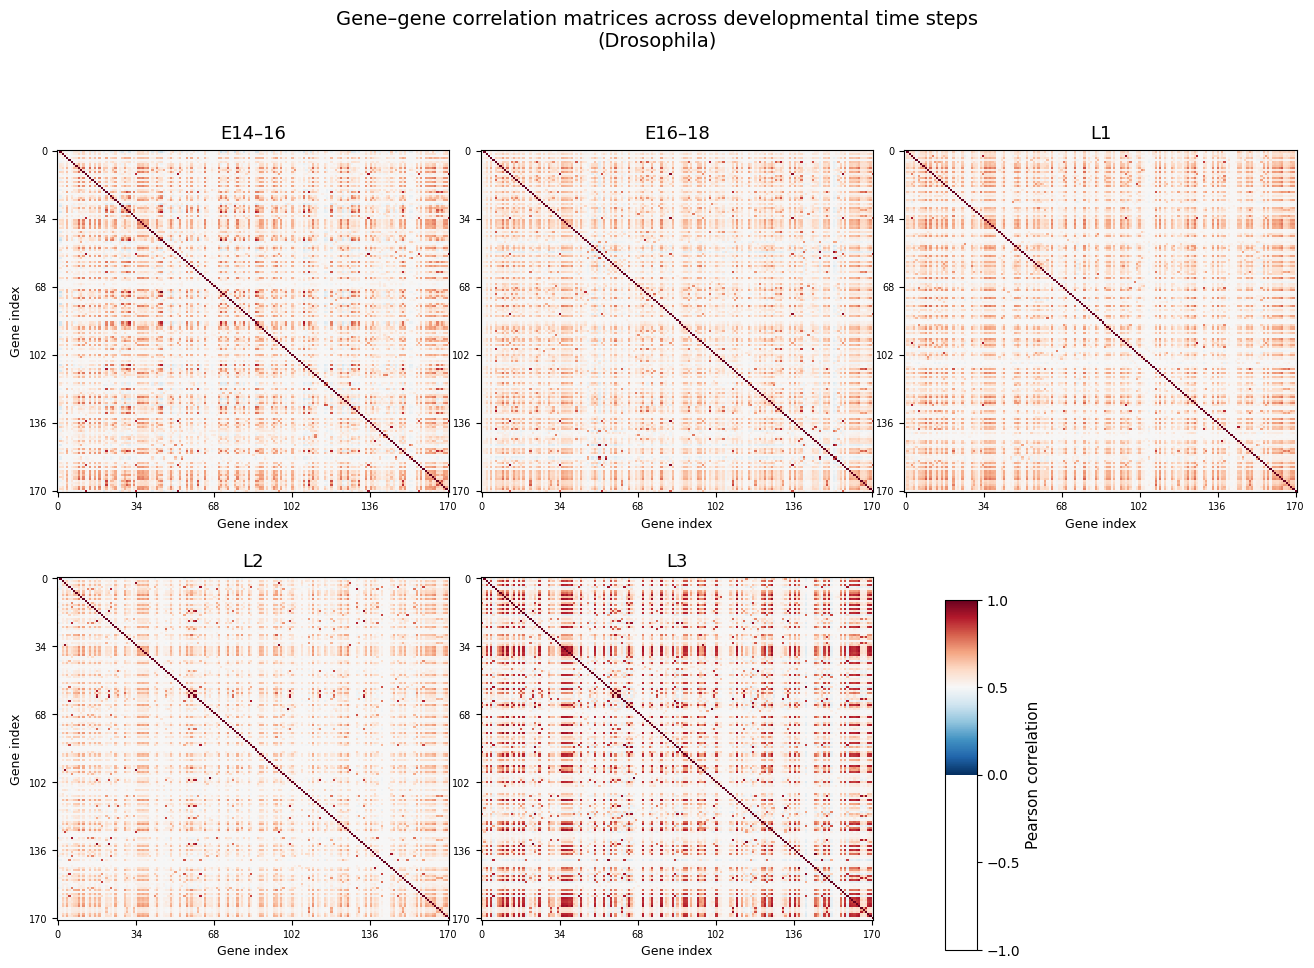

In [3]:
corr_matrices = {
    'E14–16': corr_t1,
    'E16–18': corr_t2,
    'L1':     corr_t3,
    'L2':     corr_t4,
    'L3':     corr_t5,
}

# --- Shared color scale across all panels ---
vmin, vmax = 0, 1

fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 10),
    gridspec_kw={'wspace': 0.08, 'hspace': 0.25}
)

axes_flat = axes.flatten()

for ax, (label, corr) in zip(axes_flat, corr_matrices.items()):
    mat = corr.values

    im = ax.imshow(
        mat,
        cmap='RdBu_r',
        vmin=vmin,
        vmax=vmax,
        aspect='auto',
        interpolation='nearest',
    )

    ax.set_title(label, fontsize=13, pad=8)
    ax.set_xlabel('Gene index', fontsize=9)

    n = mat.shape[0]
    tick_positions = np.linspace(0, n - 1, 6, dtype=int)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_positions, fontsize=7)
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(tick_positions, fontsize=7)

axes[0, 0].set_ylabel('Gene index', fontsize=9)
axes[1, 0].set_ylabel('Gene index', fontsize=9)

axes[1, 2].set_visible(False)

# Single shared colorbar occupying the space of the empty cell
cbar_ax = fig.add_axes([0.68, 0.08, 0.02, 0.35])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar.set_label('Pearson correlation', fontsize=11)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])

fig.suptitle(
    'Gene–gene correlation matrices across developmental time steps\n'
    '(Drosophila)',
    fontsize=14,
    y=1.02,
)

plt.savefig('correlation_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

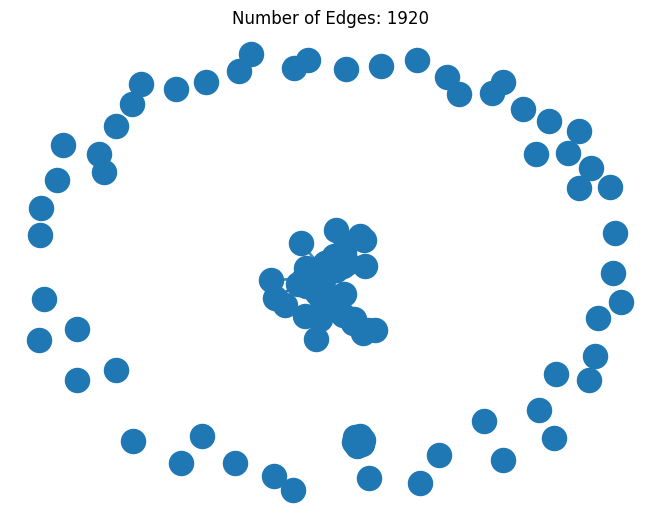

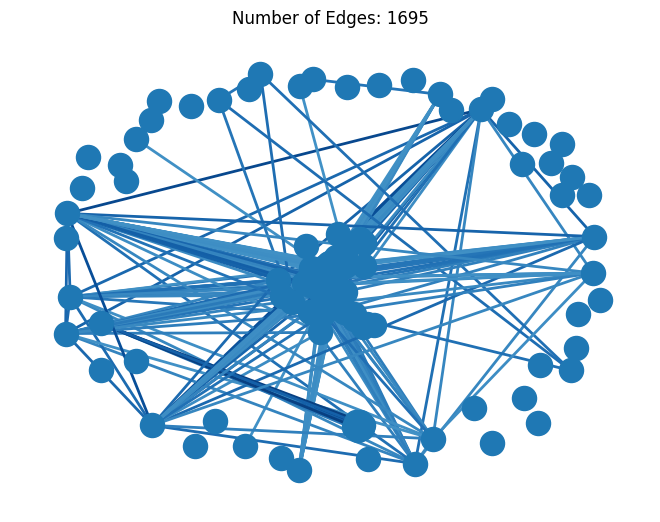

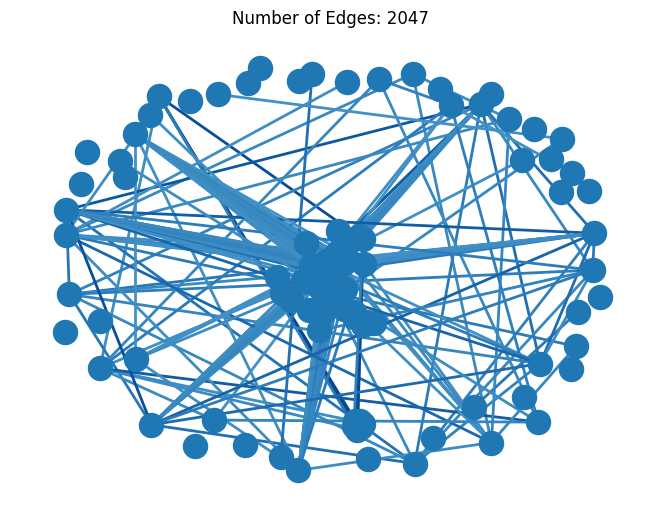

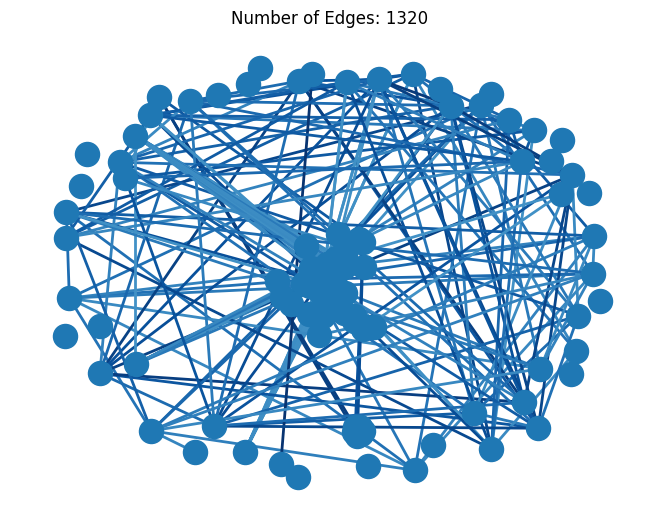

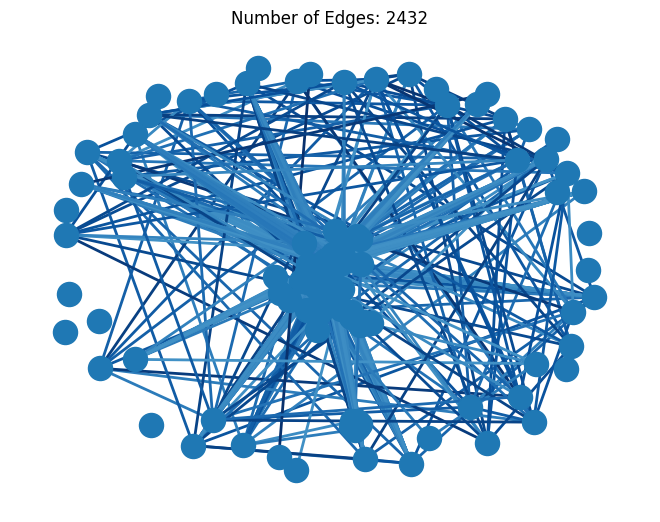

In [4]:
threshold = 0.25

correlation_pd = [pd.read_csv("corr_matrix_E14_16.csv"), pd.read_csv("corr_matrix_E16_18.csv"),  pd.read_csv("corr_matrix_L1.csv"),pd.read_csv("corr_matrix_L2.csv"),pd.read_csv("corr_matrix_L3.csv")]


datas =  [dataframe.iloc[:,1:].values for dataframe in correlation_pd]
for data in datas:
    np.fill_diagonal(data, 0.5)

graphs = [nx.from_numpy_array(np.where(abs(data*2-1) >threshold,data,0)) for data in datas]

cmap = plt.cm.Blues
pos = nx.spring_layout(graphs[0])

for graph in graphs:
    fig = plt.figure()
    edges,weights = zip(*nx.get_edge_attributes(graph,'weight').items())
    nx.draw(graph, pos, edge_color=weights, width=2.0, edge_cmap=cmap,edge_vmin = 0,edge_vmax=1)
    plt.title(f"Number of Edges: {len(edges)}")

In [5]:
#geodesic for first to final
t_values_final = np.linspace(0,1,num=40)
geodesic_final,_ =compute_GW_Geodesics_weighted(graphs[0],graphs[-1], t_values_final,weight_inf_treshold=0.2, inf_treshold=1e4,threshold_down=0.75, threshold_up=1.25, delete_high_weights=False,
    )

It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|4.835547e+07|0.000000e+00|0.000000e+00
    1|6.017428e+05|7.935904e+01|4.775373e+07
    2|6.029247e+03|9.880397e+01|5.957136e+05
    3|6.029365e+01|9.899804e+01|5.968953e+03
    4|6.029367e-01|9.899997e+01|5.969072e+01
    5|6.029548e-03|9.899700e+01|5.969072e-01
    6|6.048760e-05|9.868237e+01|5.969060e-03
    7|1.230656e-06|4.815070e+01|5.925694e-05
    8|1.327681e-07|8.269216e+00|1.097888e-06
    9|1.296964e-07|2.368360e-02|3.071678e-09
   10|1.296665e-07|2.301701e-04|2.984536e-11
   11|1.296662e-07|2.301706e-06|2.984536e-13
It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|4.987510e+07|0.000000e+00|0.000000e+00
    1|8.927253e+06|4.586836e+00|4.094785e+07
    2|8.439309e+06|5.781800e-02|4.879440e+05
    3|8.434422e+06|5.794624e-04|4.887430e+03
    4|8.434373e+06|5.794757e-06|4.887514e+01
It.  |Err         
-------------------
    

In [6]:
def compute_or_curvature_gw(
    distance_matrix,
    k=5,
    sigma=None,
    reg=1e-2,
    eps=1e-8,
    graph_check=False,
    adjacency_matrix=None,
    return_full_matrix=True,
    return_metadata=False,
):
    """
    Compute Ollivier–Ricci curvature.
 
    Parameters
    ----------
    distance_matrix  : (n, n) shortest-path distance matrix.
    adjacency_matrix : (n, n) array or None.
                       When graph_check=True this must be supplied for weighted
                       graphs. Entry [i, j] > 0 iff a direct edge exists.
                       Obtain via nx.to_numpy_array(graph) *before* calling
                       Floyd-Warshall. Use None for unweighted graphs.
    k                : k-NN neighbourhood size (metric-measure mode only).
    sigma            : bandwidth for Gaussian weights (metric-measure mode).
                       Defaults to the median k-NN distance.
    reg              : Sinkhorn regularization.
    eps              : distance floor (avoids division by zero).
    graph_check      : if True graph-mode OR curvature.
                       if False k-NN metric-measure-space mode.
    return_metadata  : if True, also return a diagnostics dict.
    """
 
    n = distance_matrix.shape[0]
    curvature_matrix = np.full((n, n), np.nan)
    skipped_small_distance = 0
    ot_failures = 0
 
    # ================================================================
    # GRAPH MODE
    # ================================================================
    if graph_check:
 
        use_adjacency = adjacency_matrix is not None
 
        if use_adjacency:
            # A neighbor is any node sharing a direct edge, identified by a positive adjacency entry.
            def get_neighbors(node):
                return np.where(adjacency_matrix[node] > 0)[0]
        else:
            # Fallback for unweighted graphs: direct neighbors are at the smallest positive shortest-path distance 
            # (= 1 for unit edges).
            def get_neighbors(node):
                row = distance_matrix[node]
                positive = row[row > eps]
                if positive.size == 0:
                    return np.array([], dtype=int)
                return np.where((row > eps) & (row <= positive.min() + eps))[0]
 
        for i in range(n):
            neighbors_i = get_neighbors(i)
            if len(neighbors_i) == 0:
                continue
 
            mu_i = np.ones(len(neighbors_i)) / len(neighbors_i)
 
            for j in neighbors_i:
                d_ij = distance_matrix[i, j]
                if d_ij < eps:
                    skipped_small_distance += 1
                    continue
 
                neighbors_j = get_neighbors(j)
                if len(neighbors_j) == 0:
                    continue
 
                mu_j = np.ones(len(neighbors_j)) / len(neighbors_j)
 
                # Ground-metric cost matrix between the two neighbor sets.
                C = distance_matrix[np.ix_(neighbors_i, neighbors_j)]
                C = np.maximum(C, 0.0)
 
                try:
                    W1 = ot.sinkhorn2(mu_i, mu_j, C, reg=reg)
                except Exception:
                    ot_failures += 1
                    continue
 
                kappa = 1.0 - W1 / max(d_ij, eps)
                curvature_matrix[i, j] = kappa
                curvature_matrix[j, i] = kappa
 
        metadata = {
            "mode": "graph",
            "neighbor_source": (
                "adjacency_matrix" if use_adjacency else "min_distance_heuristic"
            ),
            "skipped_small_distance_pairs": skipped_small_distance,
            "ot_failures": ot_failures,
            "reg": reg,
        }
 
    # ================================================================
    # GENERAL METRIC MEASURE SPACE MODE
    # ================================================================
    else:
 
        knn_indices = np.argsort(distance_matrix, axis=1)[:, :k + 1]
 
        if sigma is None:
            knn_dists = []
            for i in range(n):
                knn_dists.extend(distance_matrix[i, knn_indices[i][1:]])
            sigma = np.median(knn_dists)
            if not np.isfinite(sigma) or sigma <= 0:
                sigma = 1.0
 
        for i in range(n):
            ball_i = knn_indices[i]
            #local_scale_i = max(np.mean(distance_matrix[i, ball_i[1:]]), eps)
 
            for j in ball_i[1:]:
                d_ij = distance_matrix[i, j]
                if d_ij < eps:
                    skipped_small_distance += 1
                    continue
 
                ball_j = knn_indices[j]
                support = np.union1d(ball_i, ball_j)
 
                d_i = distance_matrix[i, support]
                d_j = distance_matrix[j, support]
 
                mu_i = np.exp(-d_i**2 / sigma**2)
                mu_j = np.exp(-d_j**2 / sigma**2)
                mu_i /= mu_i.sum()
                mu_j /= mu_j.sum()
 
                C = distance_matrix[np.ix_(support, support)]
                C = 0.5 * (C + C.T)
                C = np.maximum(C, 0.0)
 
                try:
                    W1 = ot.sinkhorn2(mu_i, mu_j, C, reg=reg)
                except Exception:
                    ot_failures += 1
                    continue
 
                kappa = (1.0 - W1 / max(d_ij, eps)) #/ local_scale_i
                curvature_matrix[i, j] = kappa
                curvature_matrix[j, i] = kappa
 
        metadata = {
            "mode": "metric",
            "sigma": sigma,
            "k": k,
            "skipped_small_distance_pairs": skipped_small_distance,
            "ot_failures": ot_failures,
            "reg": reg,
        }
 
    if return_metadata:
        return curvature_matrix, metadata
    return curvature_matrix


def analyze_or_curvature(
    graph_list,
    t_values,
    k=5,
    reg=1e-2,
    eps=1e-8,
    graph_check=False,
    label="data",
):
    """
    Compute OR curvature for a list of NetworkX graphs, one per t value.
 
    For graph_check=True (real weighted graphs), the adjacency matrix is
    extracted from each graph automatically and passed to
    compute_or_curvature_gw.
 
    Parameters
    ----------
    graph_list  : list of NetworkX graphs.
                  Geodesics geodesic_final  (40 graphs, graph_check=False)
                  Real data graphs          (5 graphs,  graph_check=True)
    t_values    : 1-D array of floats, same length as graph_list.
                  Geodesics t_values_final  = np.linspace(0, 1, 40)
                  Real data t_values_real   = np.array([0, 0.25, 0.5, 0.75, 1.0])
    k           : k-NN neighbourhood size (metric-measure mode only).
    reg         : Sinkhorn regularization.
    eps         : distance floor.
    graph_check : False for geodesics (metric-measure mode);
                  True  for real weighted graphs (graph mode).
    label       : string used in progress output.
 
    Returns
    -------
    curvature_evolution : {N: {t: curvature_matrix}}
    summary_statistics  : {N: {t: {"mean", "median", "q1", "q3", "iqr"}}}
 
    The N key is set to the node count of the first graph.
    """
    assert len(graph_list) == len(t_values), (
        f"graph_list ({len(graph_list)}) and t_values ({len(t_values)}) "
        "must have the same length."
    )
 
    N = graph_list[0].number_of_nodes()
    curvature_evolution = {N: {}}
    summary_statistics  = {N: {}}
 
    for graph, t in zip(graph_list, t_values):
        print(f"\n[{label}] t={t:.4f}  "
              f"nodes={graph.number_of_nodes()}  edges={graph.number_of_edges()}")
 
        distance_matrix = nx.floyd_warshall_numpy(graph)
 
        if graph_check:
            adjacency_matrix = nx.to_numpy_array(graph)
            # Confirm at least some edges are present
            n_edges = np.count_nonzero(adjacency_matrix)
            print(f"  Adjacency non-zero entries: {n_edges}  "
                  f"(direct edges in graph: {graph.number_of_edges()})")
        else:
            adjacency_matrix = None
 
        curvature_matrix, meta = compute_or_curvature_gw(
            distance_matrix,
            k=k,
            reg=reg,
            eps=eps,
            graph_check=graph_check,
            adjacency_matrix=adjacency_matrix,
            return_metadata=True,
        )
 
        curvature_evolution[N][t] = curvature_matrix
 
        mask = np.triu(np.ones_like(curvature_matrix, dtype=bool), k=1)
        vals = curvature_matrix[mask]
        vals = vals[np.isfinite(vals)]
 
        if vals.size == 0:
            print("  [WARNING] No valid curvature values — skipping statistics.")
            summary_statistics[N][t] = {
                "mean": np.nan, "median": np.nan,
                "q1": np.nan, "q3": np.nan, "iqr": np.nan,
            }
            continue
 
        q1, q3 = np.percentile(vals, [25, 75])
        summary_statistics[N][t] = {
            "mean":   np.mean(vals),
            "median": np.median(vals),
            "q1":     q1,
            "q3":     q3,
            "iqr":    q3 - q1,
        }
 
        print(f"  Valid pairs : {vals.size}")
        print(f"  Mean        : {summary_statistics[N][t]['mean']:.4f}")
        print(f"  Median      : {summary_statistics[N][t]['median']:.4f}")
        print(f"  IQR         : {summary_statistics[N][t]['iqr']:.4f}")
        print(f"  Neighbour source : {meta.get('neighbor_source', meta.get('mode'))}")
        print(f"  Skipped d<eps    : {meta['skipped_small_distance_pairs']}")
        print(f"  OT failures      : {meta['ot_failures']}")
 
    return curvature_evolution, summary_statistics

 
def classify_real_graphs_asymmetric(
    curvature_evolution_geo,
    curvature_evolution_real,
    t_values_geo,
    t_values_real,
    method="wasserstein",
    scalar_stat="mean",
    kl_bandwidth=None,
    standardization="shared",   # "shared" or "independent"
    verbose=True,
):
    """
    Classify each real graph to its nearest geodesic time point when the two
    trajectories live on different t-value grids.
 
    Parameters
    ----------
    curvature_evolution_geo  : {N: {t: curvature_matrix}} for geodesic_final
    curvature_evolution_real : {N: {t: curvature_matrix}} for real graphs
    t_values_geo   : array of 40 floats (geodesic grid)
    t_values_real  : array of 5  floats (real data grid)
    method         : 'wasserstein', 'kl', or 'scalar'
    scalar_stat    : 'mean' or 'median'  (used when method='scalar')
    kl_bandwidth   : KDE bandwidth for KL method; None = Scott's rule
    standardization: 'shared' or 'independent'
    verbose        : print per-graph results
 
    Returns
    -------
    dict with keys:
        'true_t'          : t_values_real
        'predicted_t'     : predicted geodesic t* for each real graph
        'predicted_index' : index into t_values_geo for each prediction
        'distance_matrix' : (n_real x n_geo) array of pairwise discrepancies
        'kendall_tau', 'kendall_pvalue', 'spearman_rho', 'spearman_pvalue'
    """
    from scipy.stats import wasserstein_distance, kendalltau, spearmanr, gaussian_kde
    import warnings
 
    # ---- Import delta helpers from whichever standardization file is active ----
    if standardization == "shared":
        from curvature_classification_shared import (
            _extract_curvature_values, _wasserstein_delta,
            _kl_delta, _scalar_delta_shared, _standardize_shared,
        )
        use_shared = True
    else:
        from curvature_classification_independent import (
            _extract_curvature_values, _wasserstein_delta,
            _kl_delta, _scalar_delta, _standardize_independent,
        )
        use_shared = False
 
    N_geo  = list(curvature_evolution_geo.keys())[0]
    N_real = list(curvature_evolution_real.keys())[0]
 
    if method not in ("wasserstein", "kl", "scalar"):
        raise ValueError(f"method must be 'wasserstein', 'kl', or 'scalar'.")
 
    std_label = "shared (geodesic-ref.)" if use_shared else "independent"
    method_labels = {
        "wasserstein": f"Wasserstein ({std_label} std)",
        "kl":          f"Sym. KL divergence ({std_label} std)",
        "scalar":      f"Scalar ({scalar_stat}) [{'shared std' if use_shared else 'raw'}]",
    }
 
    geo_vals = {
        t: _extract_curvature_values(curvature_evolution_geo, N_geo, t)
        for t in t_values_geo
    }
 
    n_real = len(t_values_real)
    n_geo  = len(t_values_geo)
    distance_matrix = np.full((n_real, n_geo), np.nan)
    predicted_t     = []
    predicted_idx   = []
 
    if verbose:
        print(f"\n{'='*66}")
        print(f"  Curvature Classification  (asymmetric grids)")
        print(f"  Standardization : {std_label}")
        print(f"  Discrepancy     : {method_labels[method]}")
        print(f"  Geodesic points : {n_geo}   Real points : {n_real}")
        print(f"{'='*66}")
 
    for i, t_real in enumerate(t_values_real):
        real_v = _extract_curvature_values(curvature_evolution_real, N_real, t_real)
 
        if real_v.size == 0:
            warnings.warn(f"Empty curvature array for real graph at t={t_real}.")
            predicted_t.append(np.nan)
            predicted_idx.append(-1)
            continue
 
        distances = []
        for j, t_geo in enumerate(t_values_geo):
            geo_v = geo_vals[t_geo]
            if geo_v.size == 0:
                distances.append(np.inf)
                continue
 
            if method == "scalar":
                if use_shared:
                    d = _scalar_delta_shared(real_v, geo_v, stat=scalar_stat)
                else:
                    d = _scalar_delta(real_v, geo_v, stat=scalar_stat)
            
            elif method == "wasserstein":
                d = _wasserstein_delta(real_v, geo_v)
            
            else:  # "kl"
                # Standardize before KL
                if use_shared:
                    a, b = _standardize_shared(real_v, geo_v)
                else:
                    a, b = _standardize_independent(real_v, geo_v)
                d = _kl_delta(a, b, bandwidth=kl_bandwidth)
 
            distance_matrix[i, j] = d
            distances.append(d)
 
        best_j   = int(np.argmin(distances))
        t_star   = t_values_geo[best_j]
        predicted_t.append(t_star)
        predicted_idx.append(best_j)
 
        if verbose:
            print(f"\n  Real graph t={t_real:.4f}")
            print(f"    Predicted geodesic t* = {t_star:.4f}  (index {best_j}/{n_geo-1})")
            print(f"    Min discrepancy       = {distances[best_j]:.4f}")
 
    # ---- Rank correlation on the 5 predicted positions ----
    true_ranks = np.arange(n_real, dtype=float)
    pred_ranks = np.array(predicted_idx, dtype=float)
    pred_ranks[pred_ranks < 0] = np.nan
 
    valid = np.isfinite(pred_ranks)
    n_valid = valid.sum()
 
    if n_valid < 2 or np.all(pred_ranks[valid] == pred_ranks[valid][0]):
        tau, tau_p, rho, rho_p = np.nan, np.nan, np.nan, np.nan
        if verbose:
            print("\n  [WARNING] Predictions collapsed — rank correlation undefined.")
    else:
        from scipy.stats import kendalltau, spearmanr
        tau, tau_p = kendalltau(true_ranks[valid], pred_ranks[valid])
        rho, rho_p = spearmanr(true_ranks[valid], pred_ranks[valid])
 
    fmt = lambda v: f"{v:.4f}" if np.isfinite(v) else "nan"
    if verbose:
        print(f"\n{'='*66}")
        print(f"  Rank Correlation Results")
        print(f"  True ordering     : {list(range(n_real))}")
        print(f"  Predicted indices : {predicted_idx}")
        print(f"  Predicted t*      : {[f'{p:.4f}' for p in predicted_t]}")
        print(f"\n  Kendall's tau  : {fmt(tau)}  (p = {fmt(tau_p)})")
        print(f"  Spearman's rho : {fmt(rho)}  (p = {fmt(rho_p)})")
        print(f"{'='*66}\n")
 
    return {
        "true_t":          list(t_values_real),
        "predicted_t":     predicted_t,
        "predicted_index": predicted_idx,
        "distance_matrix": distance_matrix,
        "kendall_tau":     tau,
        "kendall_pvalue":  tau_p,
        "spearman_rho":    rho,
        "spearman_pvalue": rho_p,
    }
 
 
def compare_methods_asymmetric(
    curvature_evolution_geo,
    curvature_evolution_real,
    t_values_geo,
    t_values_real,
    kl_bandwidth=None,
    standardization="shared",
):
    """
    Run all four classification variants on asymmetric grids and print a
    side-by-side summary.
 
    Returns
    -------
    results_w, results_kl, results_sc_mean, results_sc_med : dicts
    """
    shared_args = dict(
        curvature_evolution_geo=curvature_evolution_geo,
        curvature_evolution_real=curvature_evolution_real,
        t_values_geo=t_values_geo,
        t_values_real=t_values_real,
        kl_bandwidth=kl_bandwidth,
        standardization=standardization,
    )
 
    print("\n>>> Wasserstein...")
    r_w  = classify_real_graphs_asymmetric(**shared_args, method="wasserstein")
    print("\n>>> KL divergence...")
    r_kl = classify_real_graphs_asymmetric(**shared_args, method="kl")
    print("\n>>> Scalar mean...")
    r_sm = classify_real_graphs_asymmetric(**shared_args, method="scalar", scalar_stat="mean")
    print("\n>>> Scalar median...")
    r_sd = classify_real_graphs_asymmetric(**shared_args, method="scalar", scalar_stat="median")
 
    fmt = lambda v: f"{v:.4f}" if np.isfinite(v) else "   nan"
    print("\n" + "="*76)
    print(f"  Summary ({standardization} standardization, asymmetric grids)")
    print("="*76)
    print(f"  {'Metric':<22} {'Wasserstein':>12} {'KL':>12} {'Scalar mean':>12} {'Scalar med':>12}")
    print(f"  {'-'*72}")
    for label, key in [
        ("Kendall tau",      "kendall_tau"),
        ("Kendall p-value",  "kendall_pvalue"),
        ("Spearman rho",     "spearman_rho"),
        ("Spearman p-value", "spearman_pvalue"),
    ]:
        print(f"  {label:<22}"
              f" {fmt(r_w[key]):>12} {fmt(r_kl[key]):>12}"
              f" {fmt(r_sm[key]):>12} {fmt(r_sd[key]):>12}")
    print("="*76)
 
    return r_w, r_kl, r_sm, r_sd
 
 
def plot_classification_results_asymmetric(results, t_values_geo, t_values_real,
                                           method="wasserstein", figsize=(15, 5)):
    """
    Two-panel figure for the asymmetric case.
 
    Left  : heatmap of the (n_real x n_geo) discrepancy matrix, with the
            predicted assignment starred in each row.
    Right : true real-data index vs. predicted geodesic index, annotated
            with rank correlations.
    """
    dist_mat    = results["distance_matrix"]
    pred_idx    = results["predicted_index"]
    pred_t      = results["predicted_t"]
    tau, tau_p  = results["kendall_tau"],  results["kendall_pvalue"]
    rho, rho_p  = results["spearman_rho"], results["spearman_pvalue"]
 
    n_real = len(t_values_real)
    n_geo  = len(t_values_geo)
 
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=figsize)
 
    # ---- Heatmap (n_real rows x n_geo columns) ----
    im = ax.imshow(dist_mat, aspect="auto", cmap="YlOrRd")
    plt.colorbar(im, ax=ax, label="Discrepancy")
    ax.set_xlabel("Geodesic t index", fontsize=11)
    ax.set_ylabel("Real graph", fontsize=11)
 
    # Only show a few geodesic tick labels to avoid crowding
    geo_tick_pos = np.linspace(0, n_geo - 1, 6, dtype=int)
    ax.set_xticks(geo_tick_pos)
    ax.set_xticklabels([f"{t_values_geo[p]:.2f}" for p in geo_tick_pos], fontsize=8)
    ax.set_yticks(range(n_real))
    ax.set_yticklabels([f"{t:.2f}" for t in t_values_real], fontsize=9)
    ax.set_title(f"Pairwise Discrepancy\n(method: {method})", fontsize=12)
 
    for i in range(n_real):
        row = dist_mat[i]
        if np.any(np.isfinite(row)):
            ax.plot(int(np.nanargmin(row)), i, marker="*", color="white",
                    markersize=14, markeredgecolor="black", markeredgewidth=0.6)
 
    # ---- Scatter: true index vs predicted geodesic index ----
    true_idx_arr = np.arange(n_real)
    pred_idx_arr = np.array(pred_idx, dtype=float)
    pred_idx_arr[pred_idx_arr < 0] = np.nan
 
    ax2.scatter(true_idx_arr, pred_idx_arr, s=90, zorder=3,
                color="steelblue", edgecolors="k")
    for i in range(n_real):
        if np.isfinite(pred_idx_arr[i]):
            ax2.annotate(
                f"t={t_values_real[i]:.2f}→{pred_t[i]:.2f}",
                (true_idx_arr[i], pred_idx_arr[i]),
                textcoords="offset points", xytext=(7, 4), fontsize=8,
            )
 
    # Diagonal scaled to the geodesic grid (perfect linear mapping)
    ideal = np.linspace(0, n_geo - 1, n_real)
    ax2.plot(true_idx_arr, ideal, "--", color="gray", linewidth=1,
             label="Ideal linear mapping")
 
    ax2.set_xticks(true_idx_arr)
    ax2.set_xticklabels([f"{t:.2f}" for t in t_values_real])
    ax2.set_xlabel("True real-data time step", fontsize=11)
    ax2.set_ylabel("Predicted geodesic index", fontsize=11)
    ax2.set_title("True vs. Predicted Time Step", fontsize=12)
    ax2.legend(fontsize=9)
 
    fmt = lambda v: f"{v:.3f}" if np.isfinite(v) else "nan"
    ax2.text(0.04, 0.96,
             f"Kendall $\\tau$ = {fmt(tau)}  (p = {fmt(tau_p)})\n"
             f"Spearman $\\rho$ = {fmt(rho)}  (p = {fmt(rho_p)})",
             transform=ax2.transAxes, fontsize=9, verticalalignment="top",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow",
                       edgecolor="gray"))
 
    plt.tight_layout()
    plt.show()

In [13]:
curvature_evolution_geo, sum_stats_geo = analyze_or_curvature(
    geodesic_final, t_values_final, graph_check=True, label="geodesic"
)


[geodesic] t=0.0000  nodes=171  edges=1920
  Adjacency non-zero entries: 3840  (direct edges in graph: 1920)
  Valid pairs : 1920
  Mean        : 0.5665
  Median      : 0.6212
  IQR         : 0.4795
  Neighbour source : adjacency_matrix
  Skipped d<eps    : 0
  OT failures      : 0

[geodesic] t=0.0256  nodes=171  edges=1920
  Adjacency non-zero entries: 3840  (direct edges in graph: 1920)
  Valid pairs : 1920
  Mean        : 0.5487
  Median      : 0.6423
  IQR         : 0.4188
  Neighbour source : adjacency_matrix
  Skipped d<eps    : 0
  OT failures      : 0

[geodesic] t=0.0513  nodes=171  edges=1920
  Adjacency non-zero entries: 3840  (direct edges in graph: 1920)
  Valid pairs : 1920
  Mean        : 0.5481
  Median      : 0.6389
  IQR         : 0.4253
  Neighbour source : adjacency_matrix
  Skipped d<eps    : 0
  OT failures      : 0

[geodesic] t=0.0769  nodes=171  edges=1917
  Adjacency non-zero entries: 3834  (direct edges in graph: 1917)
  Valid pairs : 1917
  Mean        : 0

In [14]:
t_values_real = [0.0, 0.0345, 0.1552, 0.5862, 1.0]

In [8]:
curvature_evolution_real, sum_stats_real = analyze_or_curvature(
    graphs, t_values_real, graph_check=True, label="real"
)


[real] t=0.0000  nodes=171  edges=1920
  Adjacency non-zero entries: 3840  (direct edges in graph: 1920)
  Valid pairs : 1920
  Mean        : 0.5665
  Median      : 0.6212
  IQR         : 0.4795
  Neighbour source : adjacency_matrix
  Skipped d<eps    : 0
  OT failures      : 0

[real] t=0.0345  nodes=171  edges=1695
  Adjacency non-zero entries: 3390  (direct edges in graph: 1695)
  Valid pairs : 1695
  Mean        : 0.5866
  Median      : 0.7252
  IQR         : 0.5316
  Neighbour source : adjacency_matrix
  Skipped d<eps    : 0
  OT failures      : 0

[real] t=0.1552  nodes=171  edges=2047
  Adjacency non-zero entries: 4094  (direct edges in graph: 2047)
  Valid pairs : 2047
  Mean        : 0.7144
  Median      : 0.7988
  IQR         : 0.2688
  Neighbour source : adjacency_matrix
  Skipped d<eps    : 0
  OT failures      : 0

[real] t=0.5862  nodes=171  edges=1320
  Adjacency non-zero entries: 2640  (direct edges in graph: 1320)
  Valid pairs : 1320
  Mean        : 0.7355
  Median  

In [9]:
### New Data ###
import glob
import re
import os
import pandas as pd

stages = ['E14_16', 'E16_18', 'L1', 'L2', 'L3']
bootstrap_stages = ['E14_16', 'E16_18', 'L1', 'L2', 'L3']
data_dir = '.'

corr_matrices          = {stage: {} for stage in stages}
corr_matrices_new      = {stage: {} for stage in stages}
corr_matrices_bootstrap = {stage: {} for stage in bootstrap_stages}

file_variants = [
    (corr_matrices,           stages,           f'corr_{{stage}}_S*.csv',       r'_S(\d{2})\.csv$'),
    (corr_matrices_new,       stages,           f'corr_{{stage}}_S* (1).csv',   r'_S(\d{2}) \(1\)\.csv$'),
    (corr_matrices_bootstrap, bootstrap_stages, f'{{stage}}_bootstrap_*.csv',   r'_bootstrap_(\d+)\.csv$'),
]

for target_dict, stage_list, pat_template, regex in file_variants:
    for stage in stage_list:
        pattern = os.path.join(data_dir, pat_template.format(stage=stage))
        for path in sorted(glob.glob(pattern)):
            m = re.search(regex, os.path.basename(path))
            if m:
                sample_idx = int(m.group(1))
                target_dict[stage][sample_idx] = pd.read_csv(path, index_col=0)

for stage in stages:
    print(f"\n--- {stage} ---")
    print(f"  Original   : samples {sorted(corr_matrices[stage].keys())} "
          f"({len(corr_matrices[stage])} total)")
    print(f"  New        : samples {sorted(corr_matrices_new[stage].keys())} "
          f"({len(corr_matrices_new[stage])} total)")
    if stage in bootstrap_stages:
        print(f"  Bootstrap  : samples {sorted(corr_matrices_bootstrap[stage].keys())} "
              f"({len(corr_matrices_bootstrap[stage])} total)")
    else:
        print(f"  Bootstrap  : not available for {stage}")


--- E14_16 ---
  Original   : samples [1, 2, 5, 7, 8, 9, 10, 11, 12, 14] (10 total)
  New        : samples [1, 2, 5, 7, 8, 9, 10, 11, 12, 14] (10 total)
  Bootstrap  : samples [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] (10 total)

--- E16_18 ---
  Original   : samples [1, 2, 5, 7, 8, 9, 10, 11, 12, 14] (10 total)
  New        : samples [1, 2, 5, 7, 8, 9, 10, 11, 12, 14] (10 total)
  Bootstrap  : samples [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] (10 total)

--- L1 ---
  Original   : samples [1, 2, 5, 7, 8, 9, 10, 11, 12, 14] (10 total)
  New        : samples [1, 2, 5, 7, 8, 9, 10, 11, 12, 14] (10 total)
  Bootstrap  : samples [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] (10 total)

--- L2 ---
  Original   : samples [1, 2, 5, 7, 8, 9, 10, 11, 12, 14] (10 total)
  New        : samples [1, 2, 5, 7, 8, 9, 10, 11, 12, 14] (10 total)
  Bootstrap  : samples [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] (10 total)

--- L3 ---
  Original   : samples [1, 2, 5, 7, 8, 9, 10, 11, 12, 14] (10 total)
  New        : samples [1, 2, 5, 7, 8, 9, 10, 1

In [10]:
from collections import defaultdict

STAGE_T_VALUES = {
    'E14_16': 0.0,
    'E16_18': 0.0345,
    'L1':     0.1552,
    'L2':     0.5862,
    'L3':     1.0,
}
 
STAGE_ORDER = ['E14_16', 'E16_18', 'L1', 'L2', 'L3']  # true temporal order


def build_slice_graphs(corr_matrices, threshold=0.25, verbose=True):
    """
    Convert each (stage, sample_idx) correlation matrix into a thresholded
    NetworkX graph.
 
    This function drops any gene (row+column) that is entirely NaN for a
    given slice, independently per slice -- the set of missing genes can
    differ from one sample to another.
 
    Parameters
    ----------
    corr_matrices : {stage: {sample_idx: DataFrame}}  from the glob-based reader
    threshold     : edge threshold on |2*corr - 1|, matching your existing convention
    verbose       : print how many genes were dropped per slice
 
    Returns
    -------
    slice_graphs : {(stage, sample_idx): networkx.Graph}
    dropped_genes : {(stage, sample_idx): list of dropped gene names}
    """
    slice_graphs = {}
    dropped_genes = {}
 
    for stage, samples in corr_matrices.items():
        for sample_idx, df in samples.items():
            # Identify genes that are NaN across their entire row (equivalently,
            # entire column, since the missingness pattern is symmetric).
            row_nan_count = df.isna().sum(axis=1)
            empty_genes = df.index[row_nan_count == df.shape[1]]
 
            if len(empty_genes) > 0:
                df_clean = df.drop(index=empty_genes, columns=empty_genes)
            else:
                df_clean = df
 
            dropped_genes[(stage, sample_idx)] = list(empty_genes)
 
            if verbose and len(empty_genes) > 0:
                print(f"{stage}_S{sample_idx:02d}: dropped {len(empty_genes)} "
                      f"empty genes -> {df_clean.shape[0]} remaining "
                      f"(was {df.shape[0]})")
 
            # Confirm no NaNs remain after dropping.
            n_remaining_nan = df_clean.isna().sum().sum()
            if n_remaining_nan > 0:
                raise ValueError(
                    f"{stage}_S{sample_idx:02d}: {n_remaining_nan} NaN values "
                    f"remain after dropping fully-empty genes. The missing-data "
                    f"pattern for this slice is not fully explained by entirely "
                    f"empty genes -- inspect this slice manually before proceeding."
                )
 
            data = df_clean.values.astype(float)
            np.fill_diagonal(data, 0.0)
            adj = np.where(np.abs(data) > threshold, np.abs(data), 0.0)
            graph = nx.from_numpy_array(adj)
            nx.relabel_nodes(graph, dict(enumerate(df_clean.index)), copy=False)
            slice_graphs[(stage, sample_idx)] = graph
 
    return slice_graphs, dropped_genes
    

def compute_slice_curvatures(slice_graphs, analyze_or_curvature_fn, k=5, reg=1e-2,
                              eps=1e-8, graph_check=True, verbose=False):
    """
    Run the existing `analyze_or_curvature` function on every slice.
 
    Since `analyze_or_curvature` expects a list of graphs and a matching
    list of t-values, we call it once per slice with a single-element list,
    then merge the results into one flat dict keyed by (stage, sample_idx).
 
    Returns
    -------
    curvature_by_slice : {(stage, sample_idx): curvature_matrix}
    stats_by_slice      : {(stage, sample_idx): {"mean":..., "median":..., ...}}
    """
    curvature_by_slice = {}
    stats_by_slice = {}
 
    for (stage, sample_idx), graph in slice_graphs.items():
        label = f"{stage}_S{sample_idx:02d}"
        curv_evol, sum_stats = analyze_or_curvature_fn(
            [graph], [0.0], k=k, reg=reg, eps=eps,
            graph_check=graph_check, label=label,
        )
        N = list(curv_evol.keys())[0]
        curvature_by_slice[(stage, sample_idx)] = curv_evol[N][0.0]
        stats_by_slice[(stage, sample_idx)] = sum_stats[N][0.0]
 
        if verbose:
            print(f"{label}: mean={stats_by_slice[(stage, sample_idx)]['mean']:.4f}  "
                  f"median={stats_by_slice[(stage, sample_idx)]['median']:.4f}")
 
    return curvature_by_slice, stats_by_slice


def classify_all_slices(
    curvature_by_slice,
    curvature_evolution_geo,
    t_values_geo,
    method="wasserstein",
    scalar_stat="mean",
    kl_bandwidth=None,
    standardization="shared",
):
    """
    Classify every spatial slice independently against the geodesic
    reference.
 
    Returns a DataFrame with one row per slice:
        stage, sample_idx, true_t, predicted_t, predicted_index, discrepancy
    """
    import warnings
 
    if standardization == "shared":
        from curvature_classification_shared import (
            _extract_curvature_values, _wasserstein_delta,
            _kl_delta, _scalar_delta_shared, _standardize_shared,
        )
        use_shared = True
    else:
        from curvature_classification_independent import (
            _extract_curvature_values, _wasserstein_delta,
            _kl_delta, _scalar_delta, _standardize_independent,
        )
        use_shared = False
 
    N_geo = list(curvature_evolution_geo.keys())[0]
    geo_vals = {
        t: _extract_curvature_values(curvature_evolution_geo, N_geo, t)
        for t in t_values_geo
    }
 
    rows = []
    for (stage, sample_idx), curv_mat in curvature_by_slice.items():
        mask = np.triu(np.ones_like(curv_mat, dtype=bool), k=1)
        real_v = curv_mat[mask]
        real_v = real_v[np.isfinite(real_v)]
 
        if real_v.size == 0:
            warnings.warn(f"Empty curvature array for slice {stage}_S{sample_idx:02d}.")
            rows.append(dict(stage=stage, sample_idx=sample_idx,
                              true_t=STAGE_T_VALUES[stage],
                              predicted_t=np.nan, predicted_index=-1,
                              discrepancy=np.nan))
            continue
 
        distances = []
        for t_geo in t_values_geo:
            geo_v = geo_vals[t_geo]
            if geo_v.size == 0:
                distances.append(np.inf)
                continue
 
            if method == "scalar":
                d = (_scalar_delta_shared(real_v, geo_v, stat=scalar_stat) if use_shared
                     else _scalar_delta(real_v, geo_v, stat=scalar_stat))
            elif method == "wasserstein":
                d = _wasserstein_delta(real_v, geo_v)
            else:  # "kl"
                a, b = (_standardize_shared(real_v, geo_v) if use_shared
                        else _standardize_independent(real_v, geo_v))
                d = _kl_delta(a, b, bandwidth=kl_bandwidth)
 
            distances.append(d)
 
        best_j = int(np.argmin(distances))
        rows.append(dict(
            stage=stage, sample_idx=sample_idx,
            true_t=STAGE_T_VALUES[stage],
            predicted_t=t_values_geo[best_j],
            predicted_index=best_j,
            discrepancy=distances[best_j],
        ))
 
    df = pd.DataFrame(rows)
    df['stage'] = pd.Categorical(df['stage'], categories=STAGE_ORDER, ordered=True)
    df = df.sort_values(['stage', 'sample_idx']).reset_index(drop=True)
    return df


def slice_rank_correlation(results_df):
    """
    Compute Kendall's tau and Spearman's rho treating every slice as its
    own observation: true rank = the stage's position in STAGE_ORDER
    (repeated across all slices belonging to that stage), predicted rank
    = the slice's predicted geodesic index.
    """
    from scipy.stats import kendalltau, spearmanr
 
    valid = results_df[results_df['predicted_index'] >= 0].copy()
    if len(valid) < 2:
        return np.nan, np.nan, np.nan, np.nan
 
    true_rank = valid['stage'].cat.codes.values.astype(float)
    pred_rank = valid['predicted_index'].values.astype(float)
 
    if np.all(pred_rank == pred_rank[0]):
        return np.nan, np.nan, np.nan, np.nan
 
    tau, tau_p = kendalltau(true_rank, pred_rank)
    rho, rho_p = spearmanr(true_rank, pred_rank)
    return tau, tau_p, rho, rho_p

 
def plot_slice_classification_strip(results_df, figsize=(11, 5)):
    """
    Alternative view: x-axis = true stage (categorical, in order),
    y-axis = predicted geodesic index, color-coded by stage, with each
    slice as an individual point.
    """
    import matplotlib.pyplot as plt
 
    stage_colors = {
        'E14_16': '#E69F00',
        'E16_18': '#56B4E9',
        'L1':     '#009E73',
        'L2':     '#F0E442',
        'L3':     '#CC79A7',
    }
 
    fig, ax = plt.subplots(figsize=figsize)
 
    for i, stage in enumerate(STAGE_ORDER):
        sub = results_df[results_df['stage'] == stage]
        if sub.empty:
            continue
        x_jitter = np.random.uniform(-0.15, 0.15, size=len(sub))
        ax.scatter(i + x_jitter, sub['predicted_index'],
                   color=stage_colors[stage], s=70, edgecolor='black',
                   linewidth=0.6, alpha=0.85, zorder=3)
 
        # Mark the median predicted index for this stage
        med = sub['predicted_index'].median()
        ax.scatter([i], [med], marker='_', s=400, color='black', zorder=4)
 
    ax.set_xticks(range(len(STAGE_ORDER)))
    ax.set_xticklabels(STAGE_ORDER)
    ax.set_xlabel("True stage", fontsize=12)
    ax.set_ylabel("Predicted geodesic index", fontsize=12)
    ax.set_title("Per-slice predicted geodesic index by true stage\n"
                "(black tick = median prediction for that stage)", fontsize=12)
    ax.grid(alpha=0.2, axis='y')
 
    plt.tight_layout()
    plt.show()

In [11]:
slice_graphs3, dropped_genes3 = build_slice_graphs(corr_matrices_bootstrap, threshold=0.63)

E14_16_S01: dropped 2 empty genes -> 181 remaining (was 183)
E14_16_S10: dropped 2 empty genes -> 181 remaining (was 183)
E14_16_S02: dropped 4 empty genes -> 179 remaining (was 183)
E14_16_S03: dropped 4 empty genes -> 179 remaining (was 183)
E14_16_S04: dropped 2 empty genes -> 181 remaining (was 183)
E14_16_S05: dropped 3 empty genes -> 180 remaining (was 183)
E14_16_S06: dropped 1 empty genes -> 182 remaining (was 183)
E14_16_S07: dropped 4 empty genes -> 179 remaining (was 183)
E14_16_S08: dropped 2 empty genes -> 181 remaining (was 183)
E16_18_S01: dropped 2 empty genes -> 173 remaining (was 175)
E16_18_S10: dropped 1 empty genes -> 174 remaining (was 175)
E16_18_S02: dropped 3 empty genes -> 172 remaining (was 175)
E16_18_S03: dropped 1 empty genes -> 174 remaining (was 175)
E16_18_S04: dropped 3 empty genes -> 172 remaining (was 175)
E16_18_S05: dropped 3 empty genes -> 172 remaining (was 175)
E16_18_S06: dropped 2 empty genes -> 173 remaining (was 175)
E16_18_S07: dropped 1 em

In [12]:
curvature_by_slice3, stats_by_slice3 = compute_slice_curvatures(
    slice_graphs3, analyze_or_curvature, graph_check=True
)


[E14_16_S01] t=0.0000  nodes=181  edges=1820
  Adjacency non-zero entries: 3640  (direct edges in graph: 1820)
  Valid pairs : 1820
  Mean        : 0.5678
  Median      : 0.6284
  IQR         : 0.4898
  Neighbour source : adjacency_matrix
  Skipped d<eps    : 0
  OT failures      : 0

[E14_16_S10] t=0.0000  nodes=181  edges=1842
  Adjacency non-zero entries: 3684  (direct edges in graph: 1842)
  Valid pairs : 1842
  Mean        : 0.5715
  Median      : 0.6356
  IQR         : 0.4936
  Neighbour source : adjacency_matrix
  Skipped d<eps    : 0
  OT failures      : 0

[E14_16_S02] t=0.0000  nodes=179  edges=1838
  Adjacency non-zero entries: 3676  (direct edges in graph: 1838)
  Valid pairs : 1838
  Mean        : 0.5700
  Median      : 0.6326
  IQR         : 0.4802
  Neighbour source : adjacency_matrix
  Skipped d<eps    : 0
  OT failures      : 0

[E14_16_S03] t=0.0000  nodes=179  edges=1796
  Adjacency non-zero entries: 3592  (direct edges in graph: 1796)
  Valid pairs : 1796
  Mean   

In [15]:
results_df3 = classify_all_slices(
    curvature_by_slice3, curvature_evolution_geo, t_values_final,
    method="wasserstein", standardization="shared",
)

tau3, tau_p3, rho3, rho_p3 = slice_rank_correlation(results_df3)
print(f"Kendall tau = {tau3:.4f} (p={tau_p3:.4f}), Spearman rho = {rho3:.4f} (p={rho_p3:.4f})")

Kendall tau = 0.8889 (p=0.0000), Spearman rho = 0.9398 (p=0.0000)


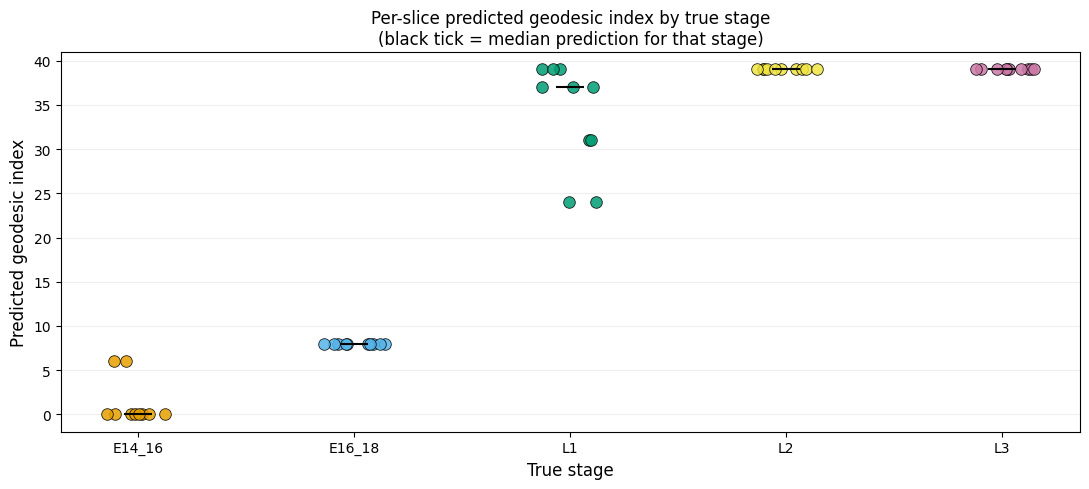

In [16]:
plot_slice_classification_strip(results_df3)

In [17]:
results_df4 = classify_all_slices(
    curvature_by_slice3, curvature_evolution_geo, t_values_final,
    method="kl", standardization="shared",
)

In [18]:
tau4, tau_p4, rho4, rho_p4 = slice_rank_correlation(results_df4)
print(f"Kendall tau = {tau4:.4f} (p={tau_p4:.4f}), Spearman rho = {rho4:.4f} (p={rho_p4:.4f})")

Kendall tau = 0.9016 (p=0.0000), Spearman rho = 0.9528 (p=0.0000)


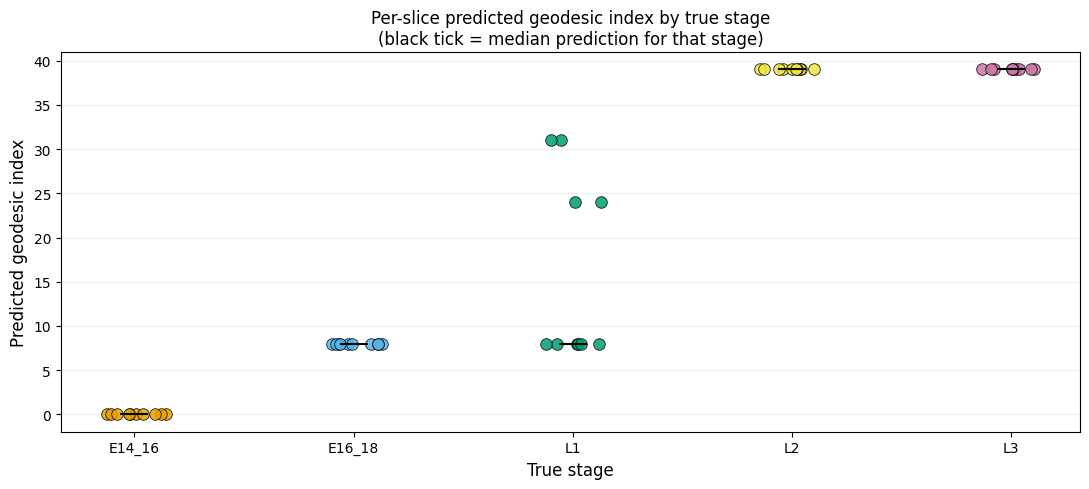

In [19]:
plot_slice_classification_strip(results_df4)

In [20]:
results_df5 = classify_all_slices(
    curvature_by_slice3, curvature_evolution_geo, t_values_final,
    method="scalar", standardization="shared",
)

In [21]:
tau5, tau_p5, rho5, rho_p5 = slice_rank_correlation(results_df5)
print(f"Kendall tau = {tau5:.4f} (p={tau_p5:.4f}), Spearman rho = {rho5:.4f} (p={rho_p5:.4f})")

Kendall tau = 0.7001 (p=0.0000), Spearman rho = 0.8323 (p=0.0000)


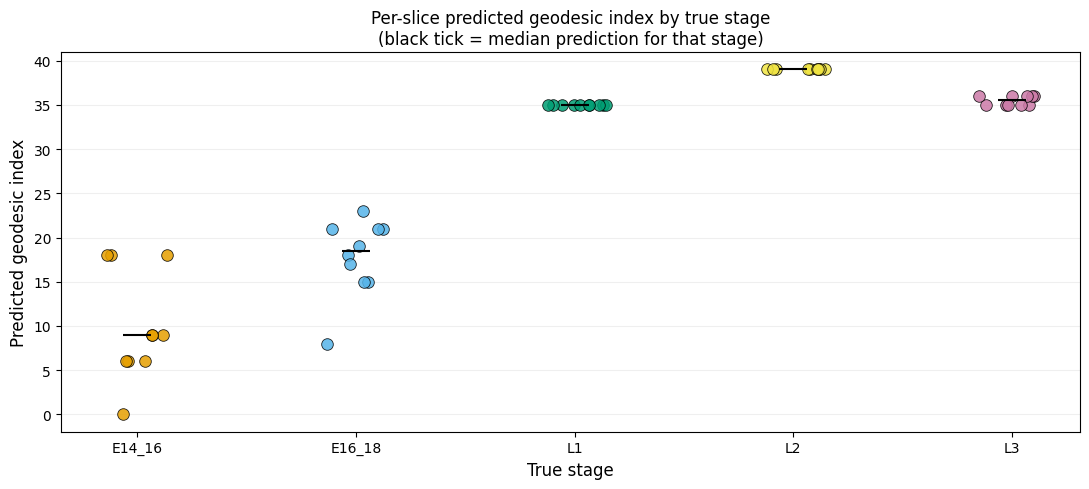

In [22]:
plot_slice_classification_strip(results_df5)

In [23]:
from slice_stage_classification import compare_methods_slice_classification

In [24]:
all_results = compare_methods_slice_classification(
    curvature_by_slice3,
    curvature_evolution_real,
)


>>> Wasserstein ...

>>> KL divergence ...

>>> Scalar mean ...

>>> Scalar median ...

  Slice-to-Stage Classification — Method Comparison
  Method                 Accuracy  N correct   Kendall tau  Spearman rho
  ------------------------------------------------------------------------
  Wasserstein              1.0000         50        1.0000        1.0000
  KL divergence            0.9400         47        0.9735        0.9867
  Scalar mean              0.7400         37        0.7098        0.8073
  Scalar median            0.6000         30        0.3162        0.4617

  Confusion matrix — Wasserstein
                  E14_16  E16_18  L1  L2  L3
True \ Predicted                            
E14_16                10       0   0   0   0
E16_18                 0      10   0   0   0
L1                     0       0  10   0   0
L2                     0       0   0  10   0
L3                     0       0   0   0  10

  Confusion matrix — KL divergence
                  E14_16  E16_18  

In [25]:
# Access individual method results
df_wass, summary_wass = all_results['Wasserstein']
print(df_wass[['true_stage', 'bootstrap_idx', 'predicted_stage', 'correct']])

   true_stage  bootstrap_idx predicted_stage  correct
0      E14_16              1          E14_16     True
1      E14_16              2          E14_16     True
2      E14_16              3          E14_16     True
3      E14_16              4          E14_16     True
4      E14_16              5          E14_16     True
5      E14_16              6          E14_16     True
6      E14_16              7          E14_16     True
7      E14_16              8          E14_16     True
8      E14_16              9          E14_16     True
9      E14_16             10          E14_16     True
10     E16_18              1          E16_18     True
11     E16_18              2          E16_18     True
12     E16_18              3          E16_18     True
13     E16_18              4          E16_18     True
14     E16_18              5          E16_18     True
15     E16_18              6          E16_18     True
16     E16_18              7          E16_18     True
17     E16_18              8

In [26]:
# Access individual method results
df_kl, summary_kl = all_results['KL divergence']
print(df_kl[['true_stage', 'bootstrap_idx', 'predicted_stage', 'correct']])

   true_stage  bootstrap_idx predicted_stage  correct
0      E14_16              1          E14_16     True
1      E14_16              2          E14_16     True
2      E14_16              3          E14_16     True
3      E14_16              4          E14_16     True
4      E14_16              5          E14_16     True
5      E14_16              6          E14_16     True
6      E14_16              7          E14_16     True
7      E14_16              8          E14_16     True
8      E14_16              9          E14_16     True
9      E14_16             10          E14_16     True
10     E16_18              1          E16_18     True
11     E16_18              2          E16_18     True
12     E16_18              3          E16_18     True
13     E16_18              4          E16_18     True
14     E16_18              5          E16_18     True
15     E16_18              6          E16_18     True
16     E16_18              7          E16_18     True
17     E16_18              8

In [27]:
# Access individual method results
df_mean, summary_mean = all_results['Scalar mean']
print(df_mean[['true_stage', 'bootstrap_idx', 'predicted_stage', 'correct']])

   true_stage  bootstrap_idx predicted_stage  correct
0      E14_16              1          E14_16     True
1      E14_16              2          E14_16     True
2      E14_16              3          E14_16     True
3      E14_16              4          E14_16     True
4      E14_16              5          E16_18    False
5      E14_16              6          E14_16     True
6      E14_16              7          E14_16     True
7      E14_16              8          E16_18    False
8      E14_16              9          E16_18    False
9      E14_16             10          E14_16     True
10     E16_18              1          E16_18     True
11     E16_18              2          E16_18     True
12     E16_18              3          E16_18     True
13     E16_18              4          E16_18     True
14     E16_18              5          E16_18     True
15     E16_18              6          E16_18     True
16     E16_18              7          E16_18     True
17     E16_18              8

In [28]:
# Access individual method results
df_med, summary_med = all_results['Scalar median']
print(df_med[['true_stage', 'bootstrap_idx', 'predicted_stage', 'correct']])

   true_stage  bootstrap_idx predicted_stage  correct
0      E14_16              1          E14_16     True
1      E14_16              2          E14_16     True
2      E14_16              3          E14_16     True
3      E14_16              4          E14_16     True
4      E14_16              5          E14_16     True
5      E14_16              6          E14_16     True
6      E14_16              7          E14_16     True
7      E14_16              8          E14_16     True
8      E14_16              9          E14_16     True
9      E14_16             10          E14_16     True
10     E16_18              1          E16_18     True
11     E16_18              2          E16_18     True
12     E16_18              3          E16_18     True
13     E16_18              4          E16_18     True
14     E16_18              5          E16_18     True
15     E16_18              6          E16_18     True
16     E16_18              7          E16_18     True
17     E16_18              8

In [38]:
def plot_discrepancy_heatmap(results_df, stage_order=STAGE_ORDER, method_label=""):
    d_cols = [f'd_{s}' for s in stage_order if f'd_{s}' in results_df.columns]
    
    # Sort rows by true stage then bootstrap index
    plot_df = results_df.sort_values(['true_stage', 'bootstrap_idx'])
    D = plot_df[d_cols].values
    
    # Row labels: "E14_16_01", etc.
    row_labels = [f"{r.true_stage}_b{r.bootstrap_idx:02d}"
                  for _, r in plot_df.iterrows()]
    
    fig, ax = plt.subplots(figsize=(7, 12))
    im = ax.imshow(D, aspect='auto', cmap='YlOrRd')
    plt.colorbar(im, ax=ax, label=f'Discrepancy ({method_label})')
    
    # Mark the predicted (argmin) cell per row
    for i, row_d in enumerate(D):
        j = int(np.argmin(row_d))
        ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                    fill=False, edgecolor='black', lw=2))
    
    # Mark the correct cell per row with a star
    for i, (_, row) in enumerate(plot_df.iterrows()):
        j = stage_order.index(row['true_stage'])
        correct = row['correct']
        ax.text(j, i, '★' if correct else '✗', ha='center', va='center',
                fontsize=9, color='black' if correct else 'black')
    
    # Stage separator lines
    stage_counts = [len(plot_df[plot_df['true_stage'] == s]) for s in stage_order]
    cumulative = np.cumsum(stage_counts)
    for c in cumulative[:-1]:
        ax.axhline(c - 0.5, color='black', linewidth=2)
    
    ax.set_xticks(range(len(stage_order)))
    ax.set_xticklabels(stage_order, rotation=30, ha='right')
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=7)
    ax.set_title(f"Per-Slice Discrepancy to Each Reference Stage\n({method_label})",
                 fontsize=12)
    plt.tight_layout()
    plt.show()

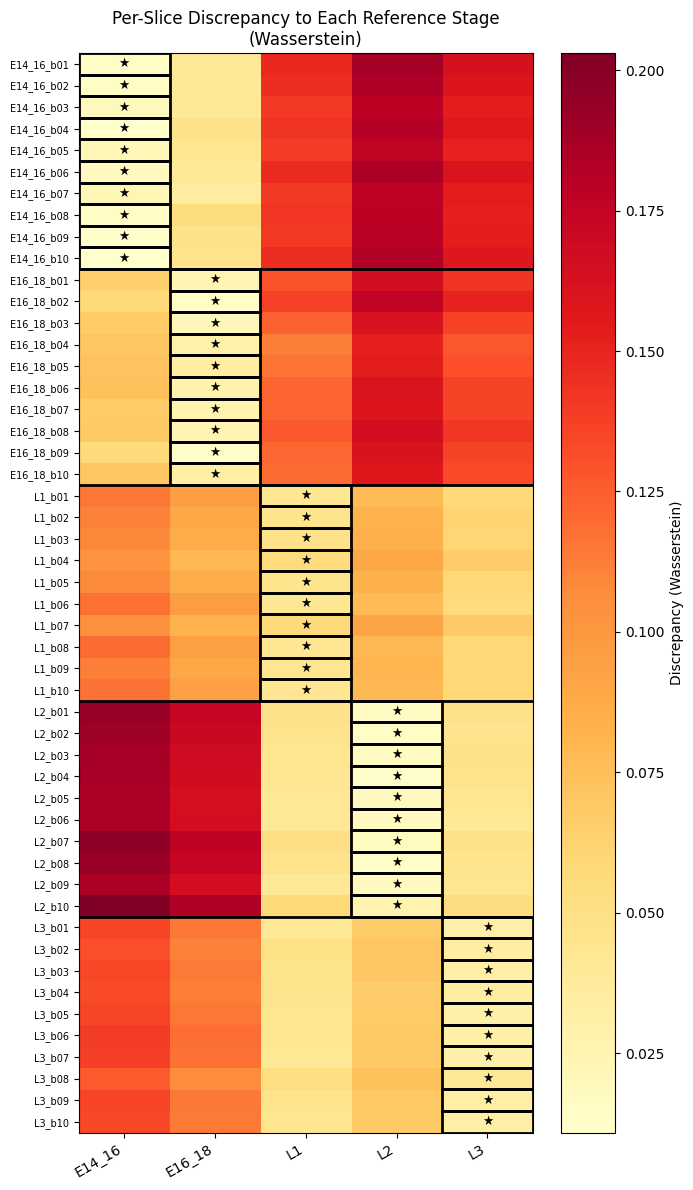

In [30]:
plot_discrepancy_heatmap(df_wass, stage_order=STAGE_ORDER, method_label="Wasserstein")

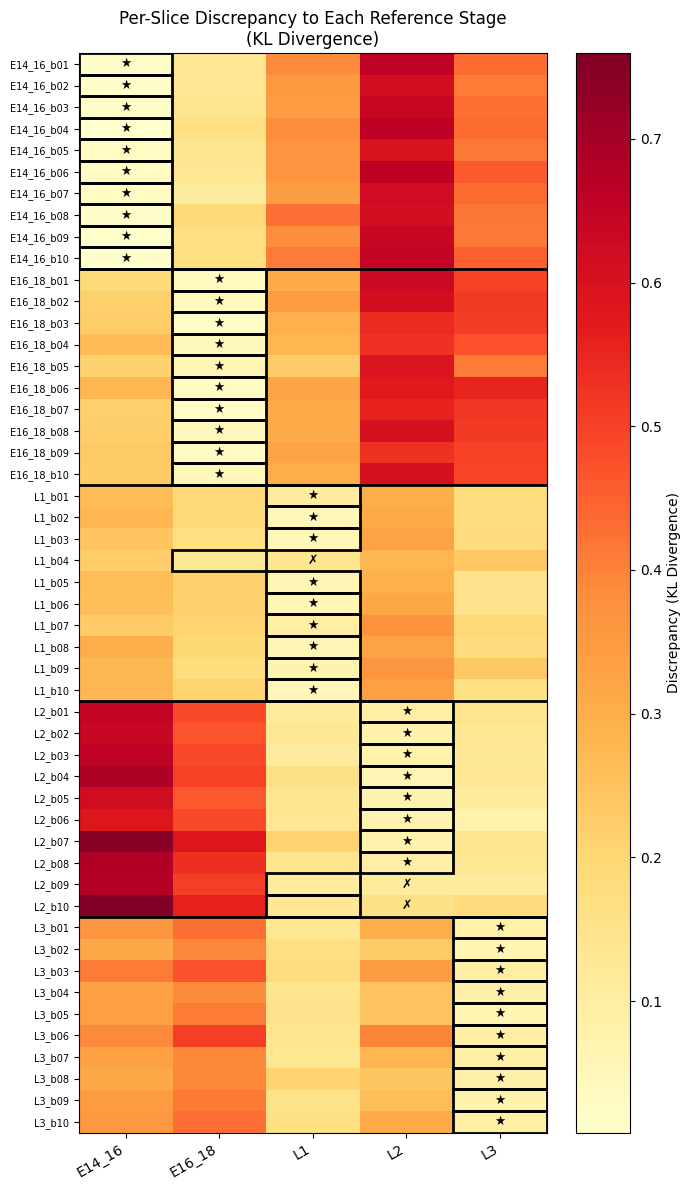

In [31]:
plot_discrepancy_heatmap(df_kl, stage_order=STAGE_ORDER, method_label="KL Divergence")

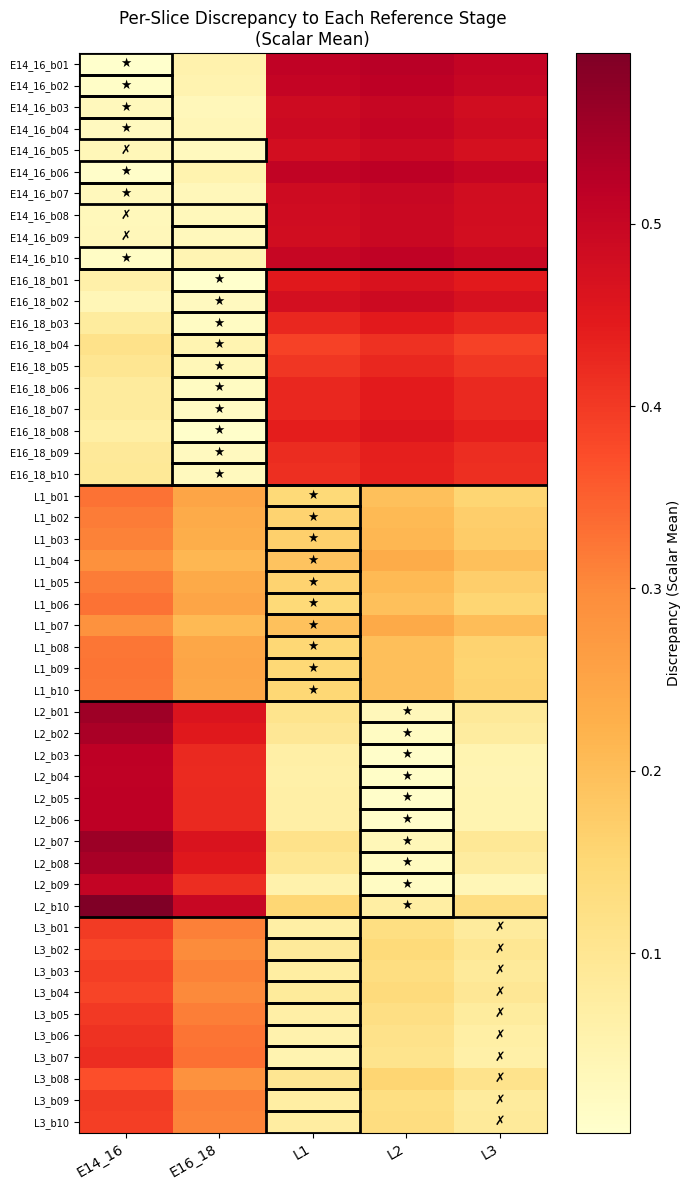

In [35]:
plot_discrepancy_heatmap(df_mean, stage_order=STAGE_ORDER, method_label="Scalar Mean")

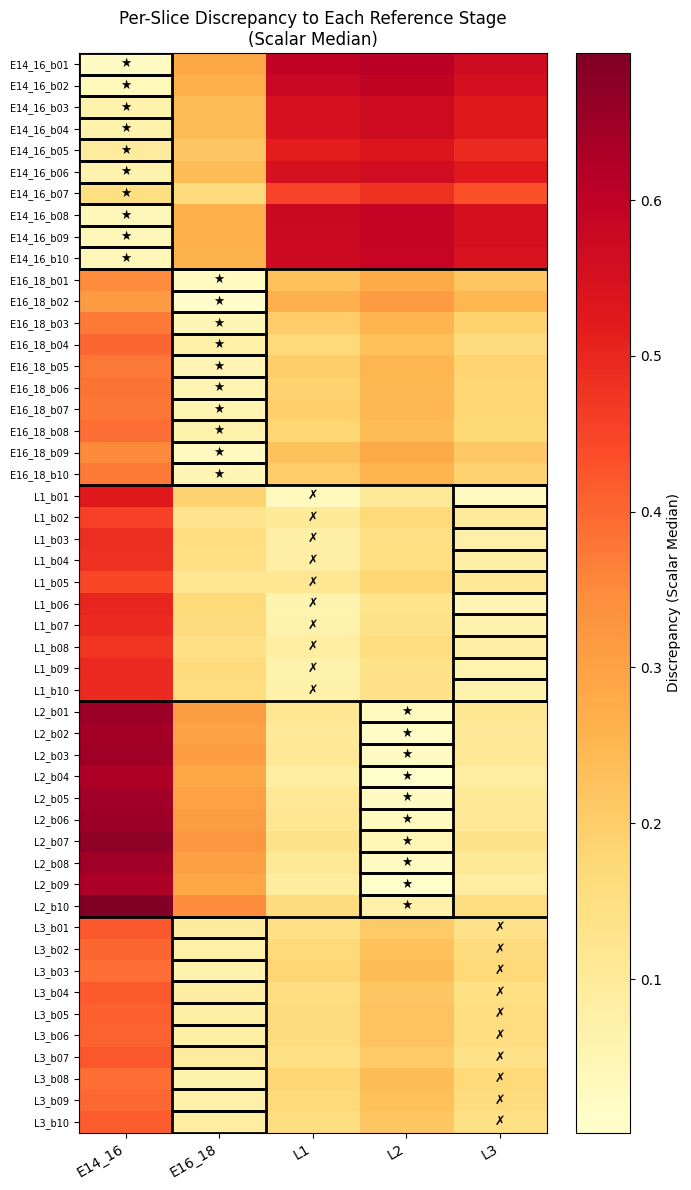

In [37]:
plot_discrepancy_heatmap(df_med, stage_order=STAGE_ORDER, method_label="Scalar Median")